# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [2]:
data = pd.read_csv("breast-cancer-wisconsin-data.csv")
data= data.drop((['ID']),axis=1)
data.head(10)

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
5,8,10,10,8,7,10,9,7,1,4
6,1,1,1,1,2,10,3,1,1,2
7,2,1,2,1,2,1,3,1,1,2
8,2,1,1,1,2,1,1,1,5,2
9,4,2,1,1,2,1,2,1,1,2


In [3]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [5]:
data.shape

(699, 10)

In [6]:
data.describe()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [7]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [8]:
data.isnull().sum()

ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [9]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [10]:
data['Bare Nuclei'].value_counts()[['?']].sum()

16

In [11]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [12]:
data['Bare Nuclei'].replace('?','0',inplace=True)

In [13]:
data['Bare Nuclei']=data['Bare Nuclei'].astype(str).astype(int)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null int64
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10)
memory usage: 54.7 KB


In [15]:
data['Bare Nuclei'].replace(to_replace=0, value = data['Bare Nuclei'].median(), inplace = True)

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [16]:
# Check for correlation of variable
corr = data.corr()
corr

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ClumpThickness,1.000000,0.644913,0.654589,0.486356,0.521816,0.590008,0.558428,0.535835,0.350034,0.716001
Cell Size,0.644913,1.000000,0.906882,0.705582,0.751799,0.686673,0.755721,0.722865,0.458693,0.817904
Cell Shape,0.654589,0.906882,1.000000,0.683079,0.719668,0.707474,0.735948,0.719446,0.438911,0.818934
Marginal Adhesion,0.486356,0.705582,0.683079,1.000000,0.599599,0.666971,0.666715,0.603352,0.417633,0.696800
Single Epithelial Cell Size,0.521816,0.751799,0.719668,0.599599,1.000000,0.583701,0.616102,0.628881,0.479101,0.682785
Bare Nuclei,0.590008,0.686673,0.707474,0.666971,0.583701,1.000000,0.674215,0.574778,0.342397,0.818968
Normal Nucleoli,0.558428,0.755721,0.735948,0.666715,0.616102,0.674215,1.000000,0.665878,0.344169,0.756616
Bland Chromatin,0.535835,0.722865,0.719446,0.603352,0.628881,0.574778,0.665878,1.000000,0.428336,0.712244
Mitoses,0.350034,0.458693,0.438911,0.417633,0.479101,0.342397,0.344169,0.428336,1.000000,0.423170
Class,0.716001,0.817904,0.818934,0.696800,0.682785,0.818968,0.756616,0.712244,0.423170,1.000000


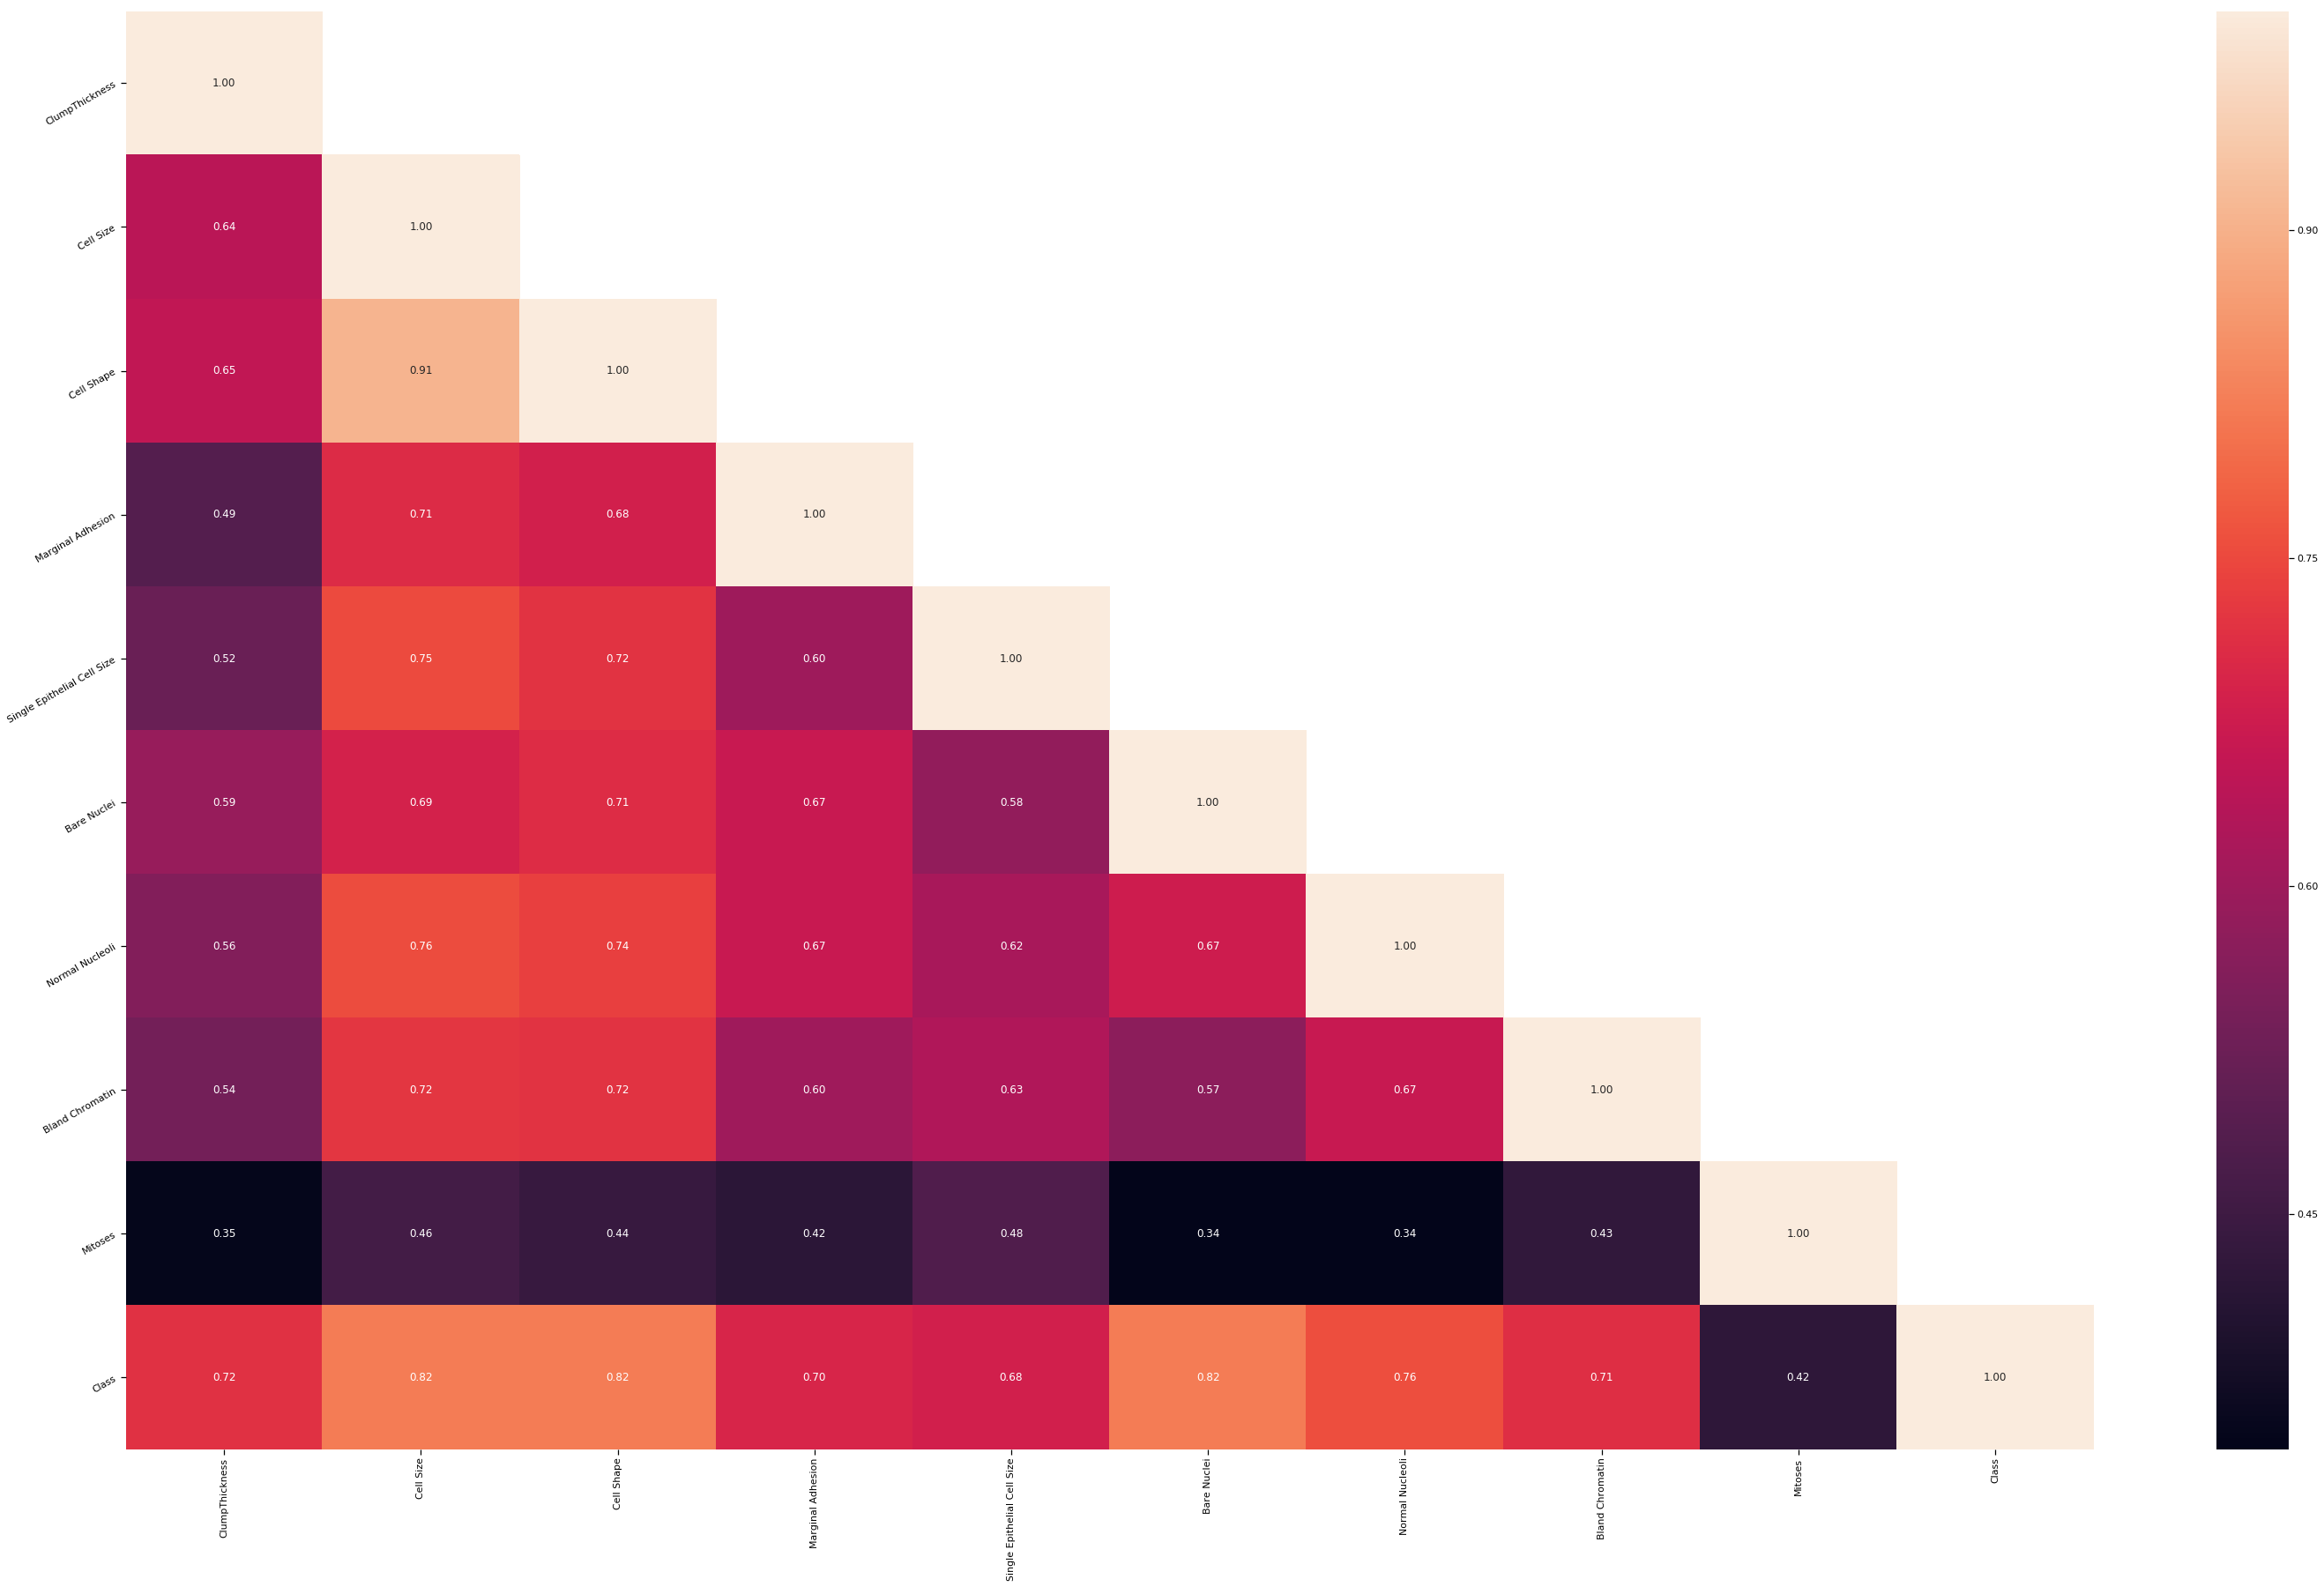

In [17]:
sns.set_context("notebook", font_scale=1.0, rc={"lines.linewidth": 3.5})
plt.figure(figsize=(50,30))
# create a mask so we only see the correlation values once
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, 1)] = True
a = sns.heatmap(corr,mask=mask, annot=True, fmt='.2f')
rotx = a.set_xticklabels(a.get_xticklabels(), rotation=90)
roty = a.set_yticklabels(a.get_yticklabels(), rotation=30)

In [18]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [19]:
#Let us check for pair plots

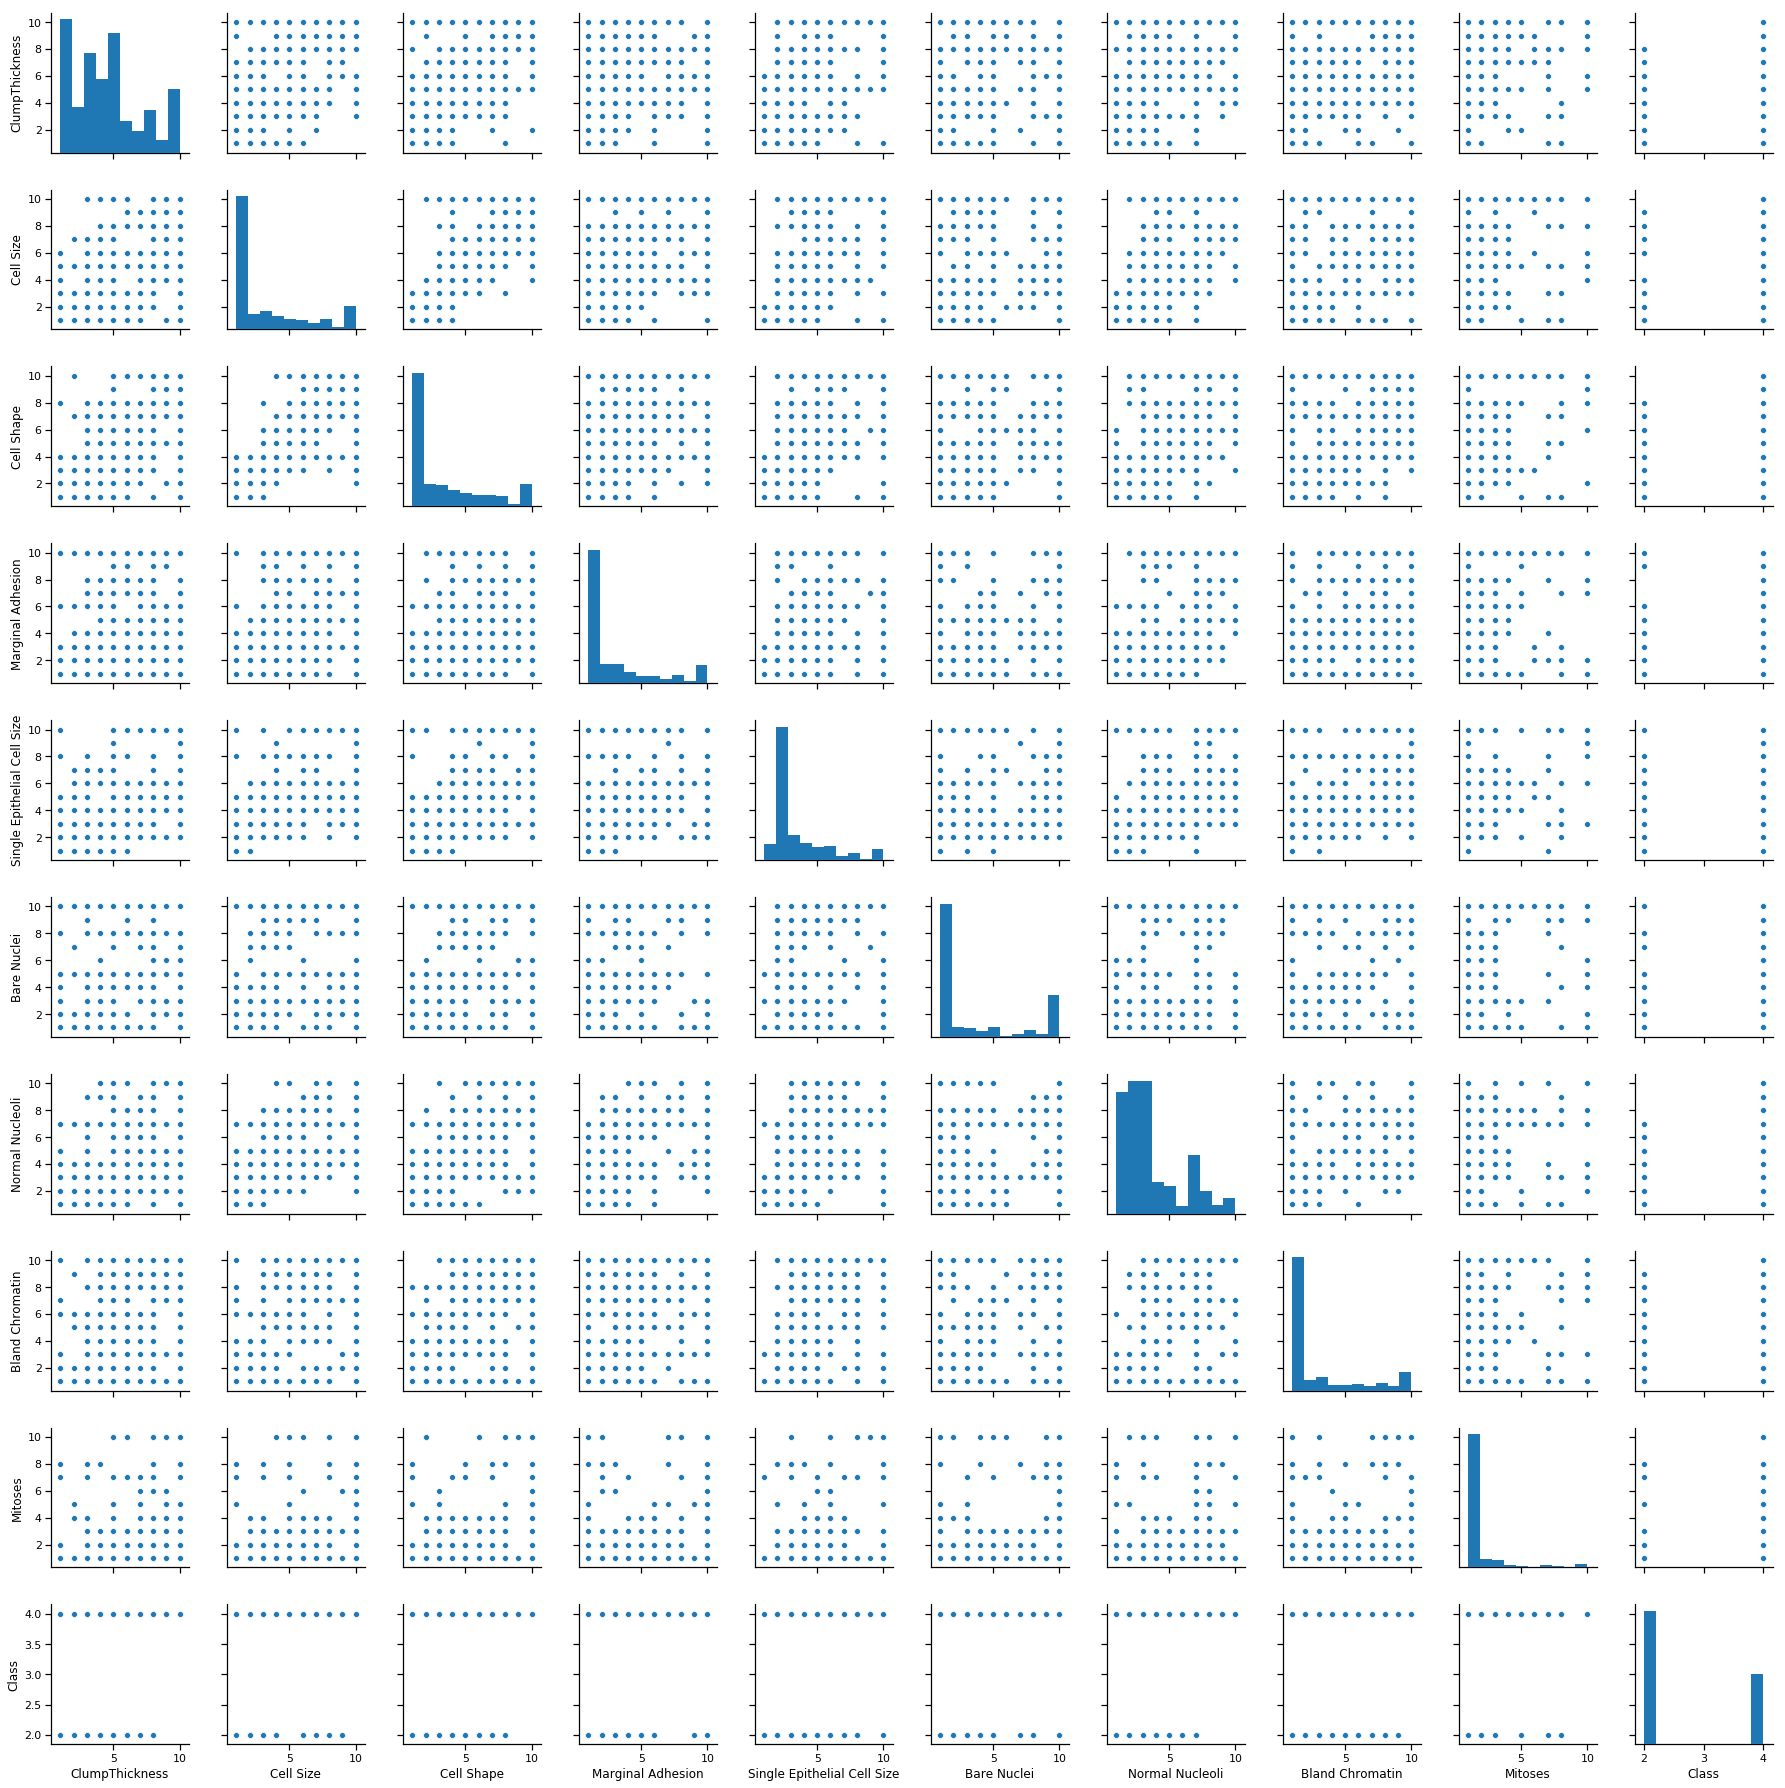

In [20]:
sns.pairplot(data)

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

ClumpThickness                    AxesSubplot(0.125,0.816017;0.065678x0.0639831)
Cell Size                      AxesSubplot(0.203814,0.816017;0.065678x0.0639831)
Cell Shape                     AxesSubplot(0.282627,0.816017;0.065678x0.0639831)
Marginal Adhesion              AxesSubplot(0.361441,0.816017;0.065678x0.0639831)
Single Epithelial Cell Size    AxesSubplot(0.440254,0.816017;0.065678x0.0639831)
Bare Nuclei                    AxesSubplot(0.519068,0.816017;0.065678x0.0639831)
Normal Nucleoli                AxesSubplot(0.597881,0.816017;0.065678x0.0639831)
Bland Chromatin                AxesSubplot(0.676695,0.816017;0.065678x0.0639831)
Mitoses                        AxesSubplot(0.755508,0.816017;0.065678x0.0639831)
Class                          AxesSubplot(0.834322,0.816017;0.065678x0.0639831)
dtype: object

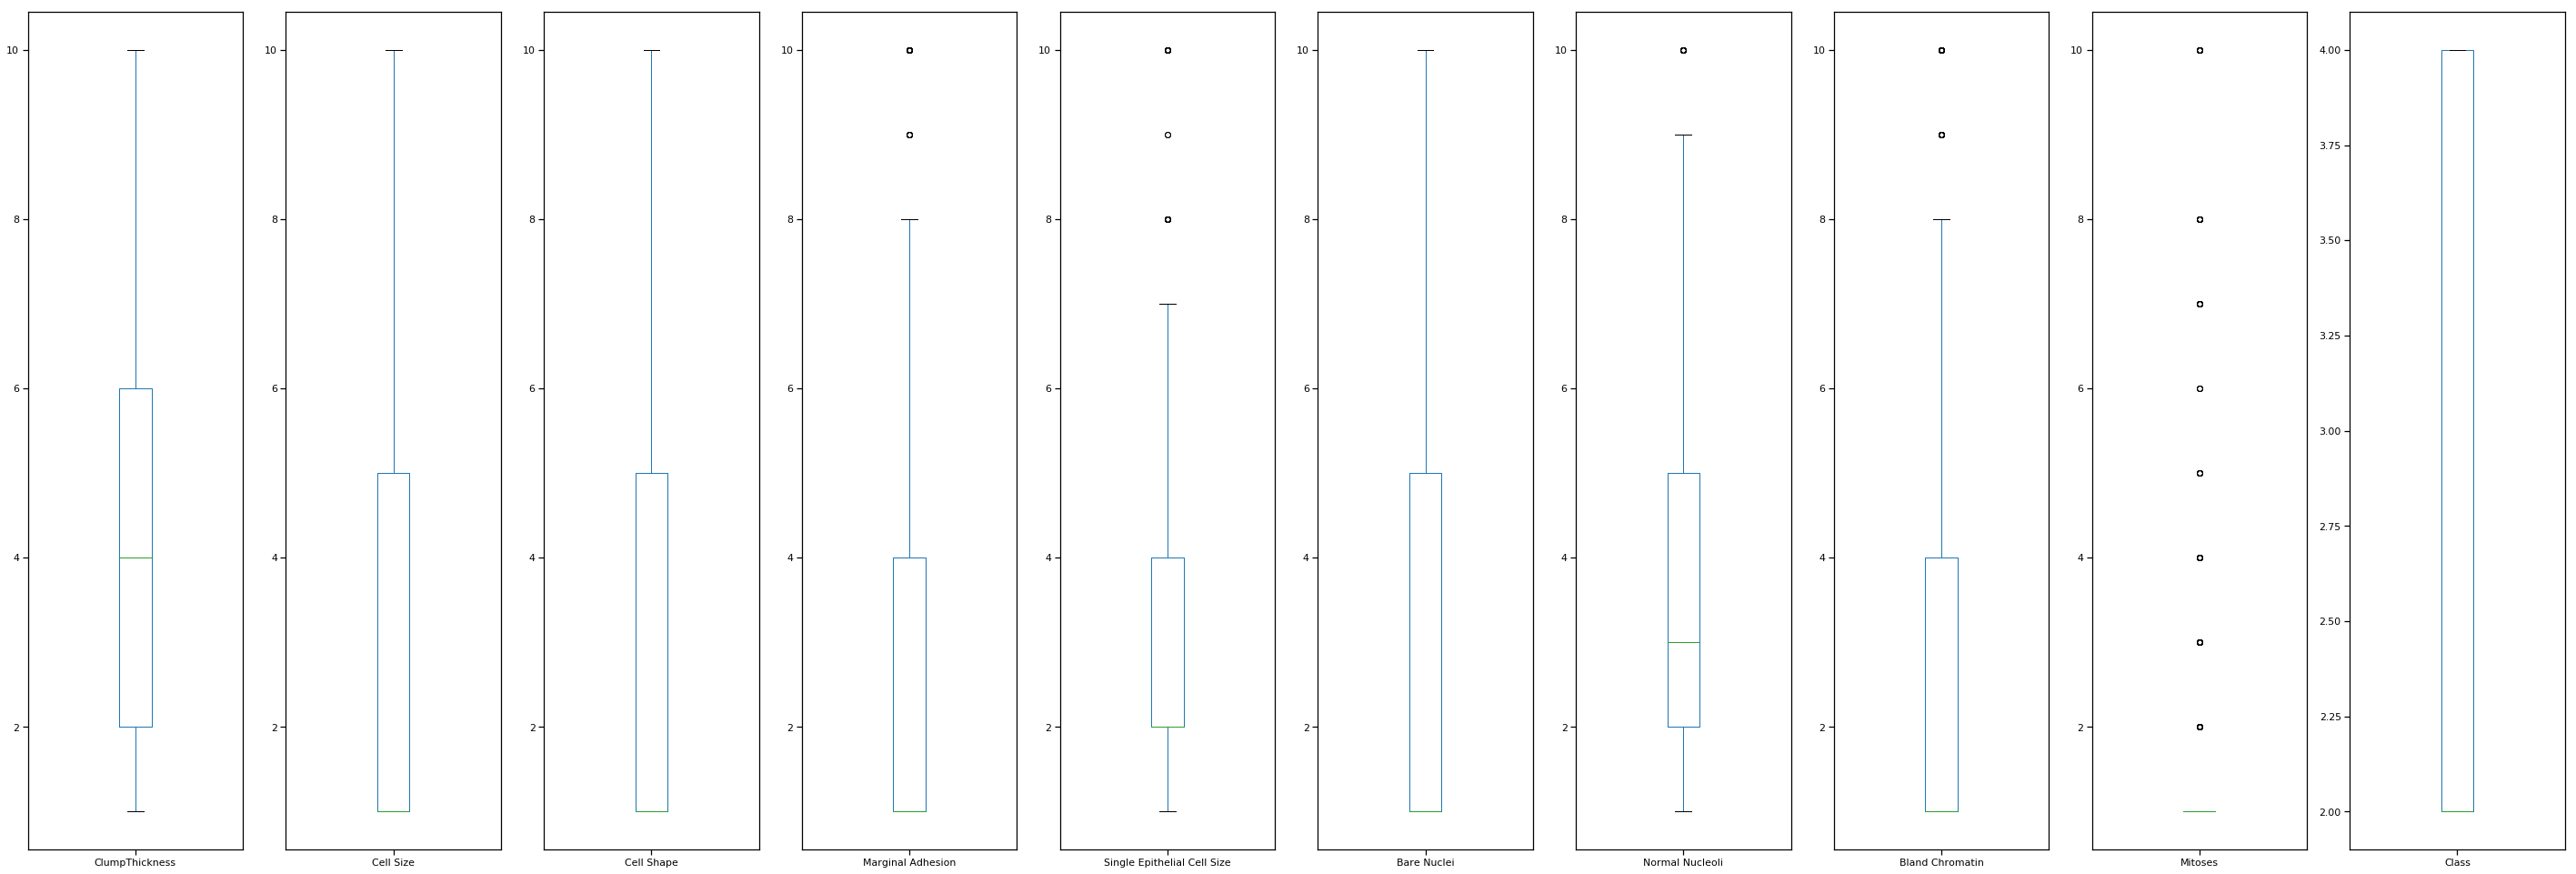

In [21]:
data.plot(kind= 'box' , subplots=True, layout=(10,10), sharex=False, sharey=False, figsize=(50,200))

In [22]:
#No Column or outliers has to be removed

In [23]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(data)

# Q6 Create a covariance matrix for identifying Principal components

In [24]:
# PCA
# Step 1 - Create covariance matrix


In [25]:
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00143266 0.64583645 0.65552689 0.48705303 0.52256381 0.5908535
  0.5592282  0.53660222 0.35053534 0.71702715]
 [0.64583645 1.00143266 0.90818117 0.70659267 0.75287621 0.68765657
  0.75680368 0.72390044 0.4593503  0.81907552]
 [0.65552689 0.90818117 1.00143266 0.68405782 0.72069948 0.70848734
  0.73700282 0.72047704 0.43953974 0.820107  ]
 [0.48705303 0.70659267 0.68405782 1.00143266 0.60045809 0.66792658
  0.66767051 0.60421681 0.41823111 0.69779849]
 [0.52256381 0.75287621 0.72069948 0.60045809 1.00143266 0.5845377
  0.61698451 0.62978166 0.47978787 0.68376273]
 [0.5908535  0.68765657 0.70848734 0.66792658 0.5845377  1.00143266
  0.67518063 0.5756016  0.34288766 0.82014124]
 [0.5592282  0.75680368 0.73700282 0.66767051 0.61698451 0.67518063
  1.00143266 0.66683179 0.34466258 0.75770012]
 [0.53660222 0.72390044 0.72047704 0.60421681 0.62978166 0.5756016
  0.66683179 1.00143266 0.42894941 0.71326403]
 [0.35053534 0.4593503  0.43953974 0.41823111 0.47978787 0.34

# Q7 Identify eigen values and eigen vector

In [26]:
# Step 2- Get eigen values and eigen vector

In [27]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-2.86482867e-01 -1.53780587e-01  8.19948678e-01 -1.93537912e-02
  -1.65922965e-01 -4.61058785e-02  5.69495446e-02 -2.43129182e-01
   3.52570674e-01 -7.26042747e-02]
 [-3.55778408e-01 -1.61465406e-02 -6.50741903e-02 -7.40430469e-01
  -4.01924327e-04 -2.22911943e-01 -1.39409782e-01  4.50063303e-01
   1.51365691e-01  1.61541178e-01]
 [-3.52927539e-01 -5.49545490e-02 -1.02133723e-02  6.48405184e-01
  -1.98081731e-01 -2.00817488e-01 -1.06583143e-01  5.84436739e-01
   7.36978525e-02  1.18181541e-01]
 [-3.09682474e-01 -8.63368905e-03 -4.09371880e-01  4.63478603e-02
   1.93963223e-02  4.69881739e-01  2.09498895e-02 -9.24327656e-02
   6.38821338e-01 -3.09916575e-01]
 [-3.11685681e-01  1.98540206e-01 -1.52492504e-01  6.56015232e-02
  -1.44016509e-02 -3.67092365e-01 -6.77581126e-01 -4.55359042e-01
  -9.99685292e-02 -1.56366046e-01]
 [-3.17155278e-01 -2.47988578e-01  3.94605610e-02 -1.12128053e-01
  -4.07592475e-01  5.32423724e-01 -1.28628247e-01  3.73420635e-02
  -5.73504501e-

# Q8 Find variance and cumulative variance by each eigen vector

In [28]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 67.15108899  75.07095961  80.5453849   85.27222156  89.07814412
  92.23047293  95.20200712  97.82728417  99.11625278 100.        ]


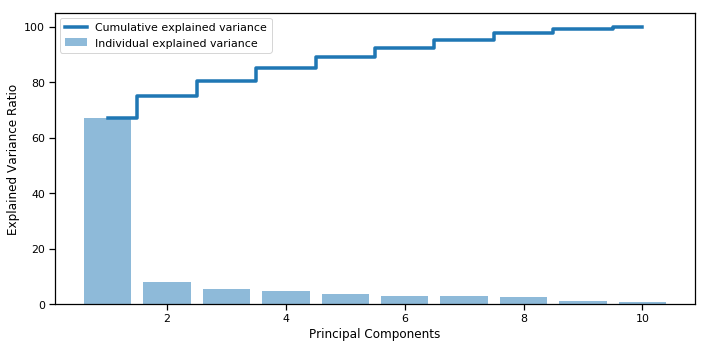

In [29]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [30]:
from sklearn.decomposition import PCA

In [31]:
X = data.drop("Class", axis=1)
y = data["Class"]

In [32]:
X_centered = X - X.mean(axis=0)

In [33]:
pca = PCA()
pca.fit(X_centered)

PCA(copy=True, iterated_power='auto', n_components=None, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [34]:
pca.components_

array([[ 0.2983261 ,  0.40439054,  0.39224516,  0.33155363,  0.25000985,
         0.43971674,  0.29212756,  0.35663675,  0.12370014],
       [-0.06201421,  0.2264635 ,  0.16441813, -0.09978919,  0.18417043,
        -0.78618671,  0.01476453,  0.4789494 ,  0.16204477],
       [-0.84870565, -0.02546854, -0.07517707,  0.48286957,  0.04907438,
         0.08447575,  0.10830834,  0.13315283,  0.03508036],
       [ 0.06534325,  0.28496176,  0.19835691,  0.39844272,  0.19968275,
        -0.30713642, -0.04657243, -0.74476283,  0.15930581],
       [-0.40932322,  0.34595861,  0.38210846, -0.63456569,  0.19340991,
         0.16587589,  0.08070772, -0.2099911 , -0.22035073],
       [-0.07699746, -0.09420965, -0.09446697, -0.1885437 ,  0.40559877,
         0.23024765, -0.47383441,  0.02554583,  0.70571044],
       [-0.02651537,  0.17476917,  0.34013253,  0.19196921, -0.27907667,
         0.05316947, -0.79645332,  0.1510127 , -0.27992292],
       [ 0.09155611, -0.12540484, -0.24132109,  0.10620924,  0

In [35]:
pca.explained_variance_

array([48.54620295,  5.17019912,  4.28609893,  3.10154865,  2.73550159,
        2.44518065,  1.77685748,  1.59407507,  0.80287437])

In [36]:
pca.explained_variance_ratio_

array([0.68900383, 0.07337931, 0.0608315 , 0.04401949, 0.03882427,
       0.03470382, 0.02521848, 0.0226243 , 0.01139499])

In [37]:
X_pca = pca.transform(X_centered)

# Q10 Find correlation between components and features

In [38]:
eig_pairs = [(eig_vals[index], eig_vecs[:,index]) for index in range(len(eig_vals))]
eig_pairs.sort()
eig_pairs.reverse()
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eig_vals))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eig_vals))]

In [39]:
P_reduce = np.array(eigvectors_sorted[0:4])   # Reducing from 8 to 4 dimension space

X_std_4D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions

Proj_data_df = pd.DataFrame(X_std_4D)  # converting array to dataframe for pairplot

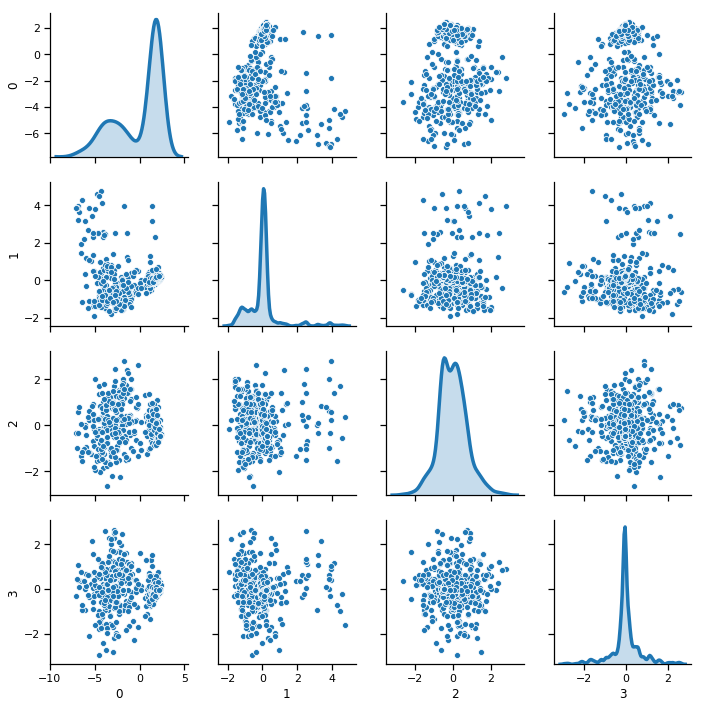

In [40]:
#Proj_data_mpg_df = Proj_data_df.join(y)

sns.pairplot(Proj_data_df, diag_kind='kde') 

In [41]:
corr1 = Proj_data_df.corr()
corr1

,0,1,2,3
0,1.000000e+00,3.407824e-16,5.010131e-16,-1.008286e-16
1,3.407824e-16,1.000000e+00,-2.764327e-16,-1.366744e-16
2,5.010131e-16,-2.764327e-16,1.000000e+00,-9.184327e-16
3,-1.008286e-16,-1.366744e-16,-9.184327e-16,1.000000e+00


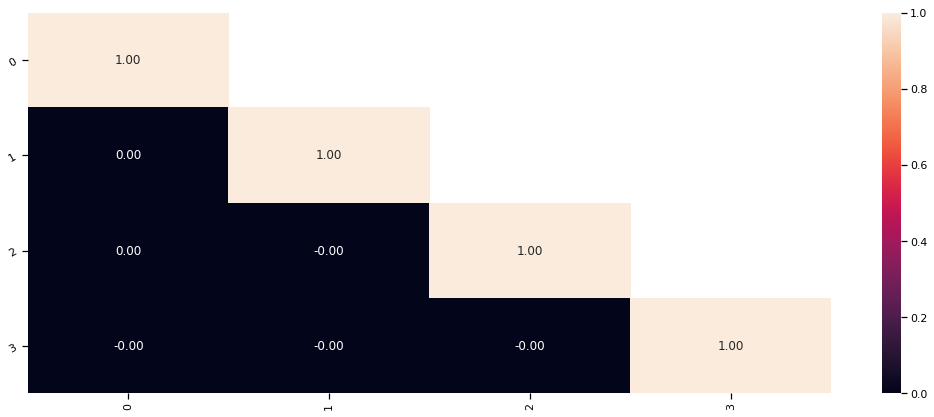

In [42]:
sns.set_context("notebook", font_scale=1.0, rc={"lines.linewidth": 3.5})
plt.figure(figsize=(18,7))
# create a mask so we only see the correlation values once
mask = np.zeros_like(corr1)
mask[np.triu_indices_from(mask, 1)] = True
a = sns.heatmap(corr1,mask=mask, annot=True, fmt='.2f')
rotx = a.set_xticklabels(a.get_xticklabels(), rotation=90)
roty = a.set_yticklabels(a.get_yticklabels(), rotation=30)